## I/ DaTscan Images

### Imports

In [ ]:
import os
import shutil
import subprocess

import pydicom
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

from skimage.restoration import estimate_sigma
from bm3d import bm3d, BM3DProfile

### display the original images (DICOM)

In [ ]:
def display_dicom_image(dicom_file, axis="x"):
    try:
        ds = pydicom.dcmread(dicom_file)
        img = ds.pixel_array

        # Take middle slice in x-axis
        if axis == "x":
            x_middle = img.shape[0] // 2
            img_slice = img[x_middle, :, :]

        # Take middle slice in y-axis
        elif axis == "y":
            y_middle = img.shape[1] // 2
            img_slice = img[:, y_middle, :]

        # Take middle slice in z-axis
        else:
            z_middle = img.shape[2] // 2
            img_slice = img[:, :, z_middle]

        plt.imshow(img_slice, cmap='gray')
        plt.title(f"DICOM: {os.path.basename(dicom_file)}")
        plt.axis('off')
        plt.show()
    except Exception as e:
        print(f"Failed to read {dicom_file}: {e}")

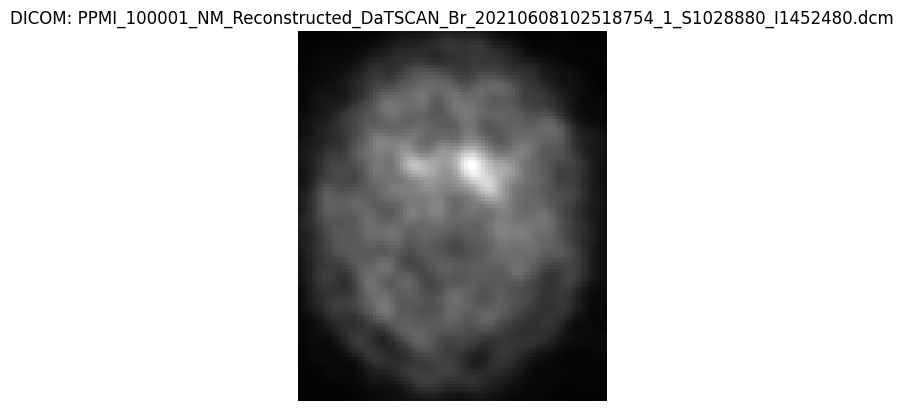

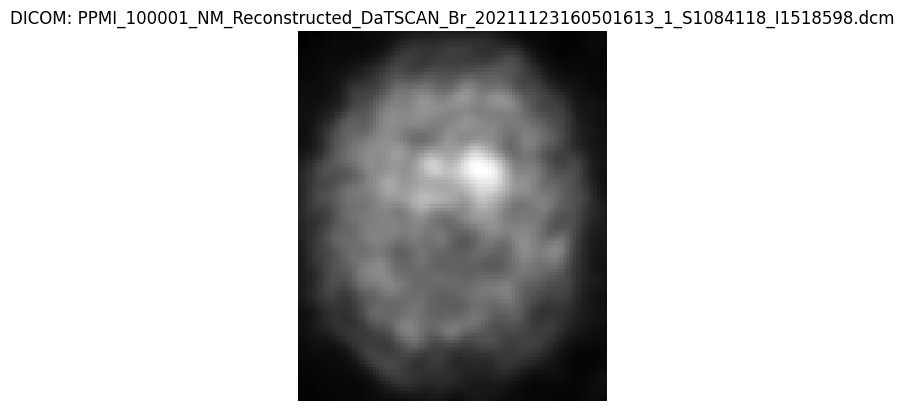

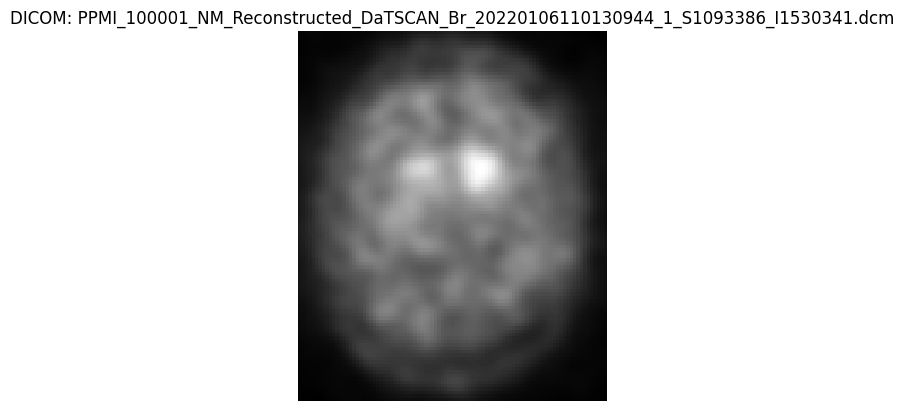

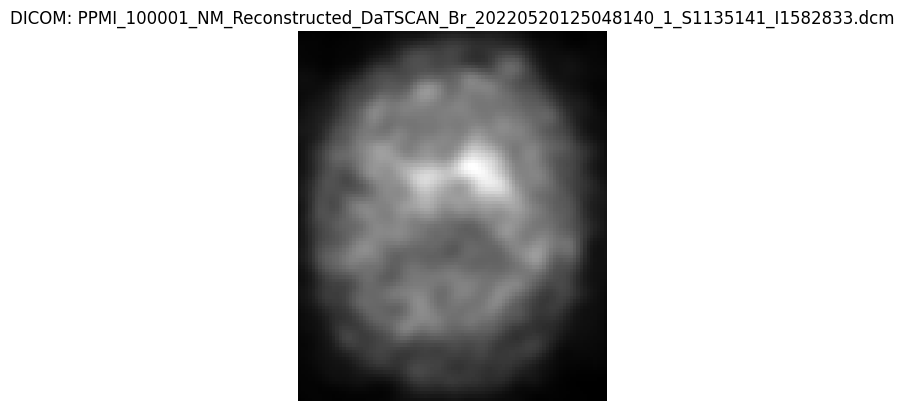

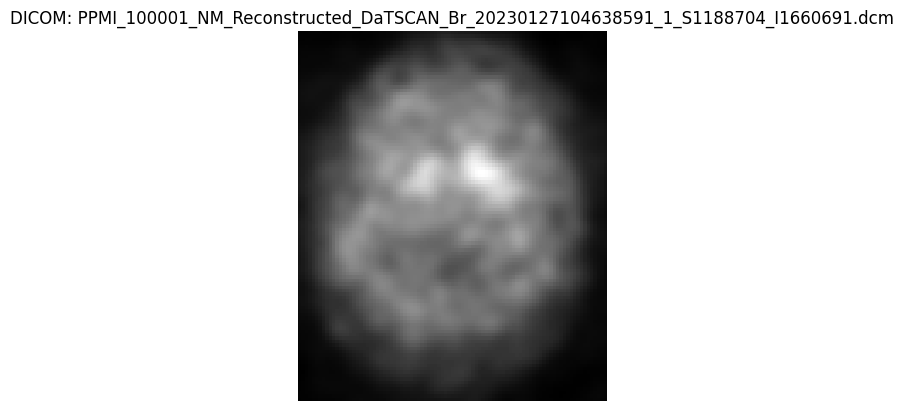

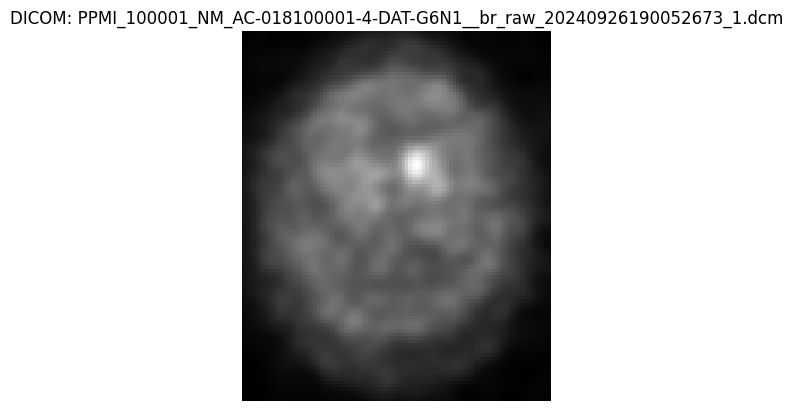

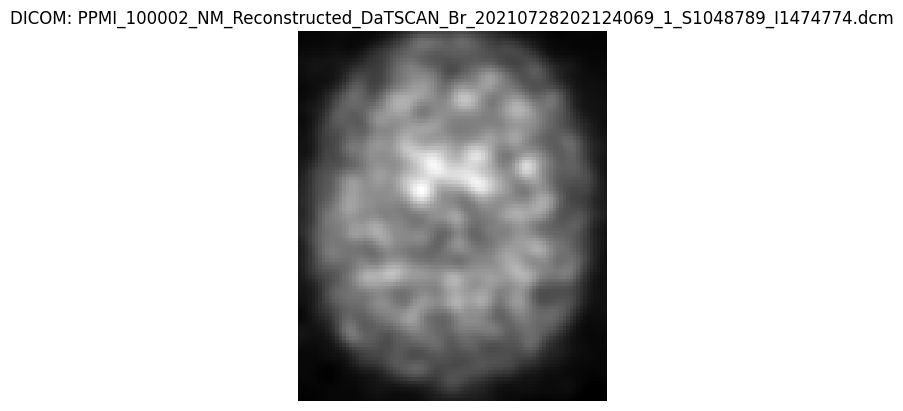

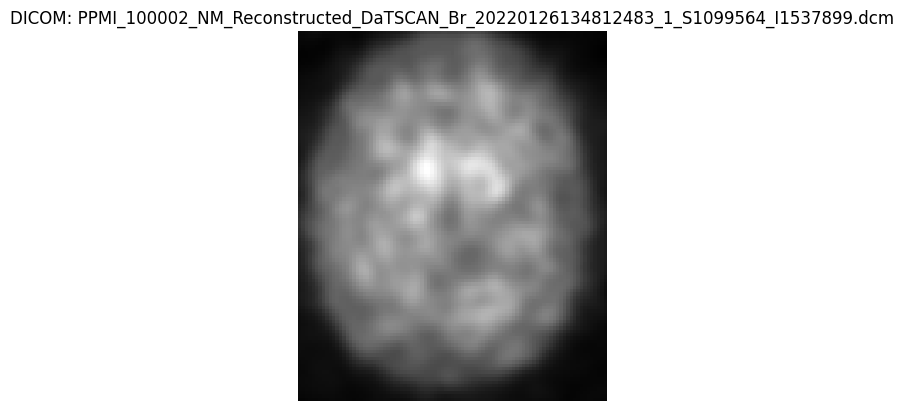

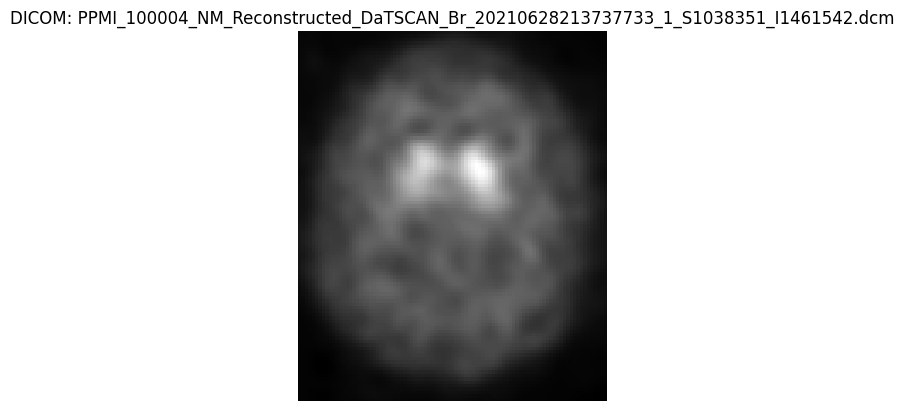

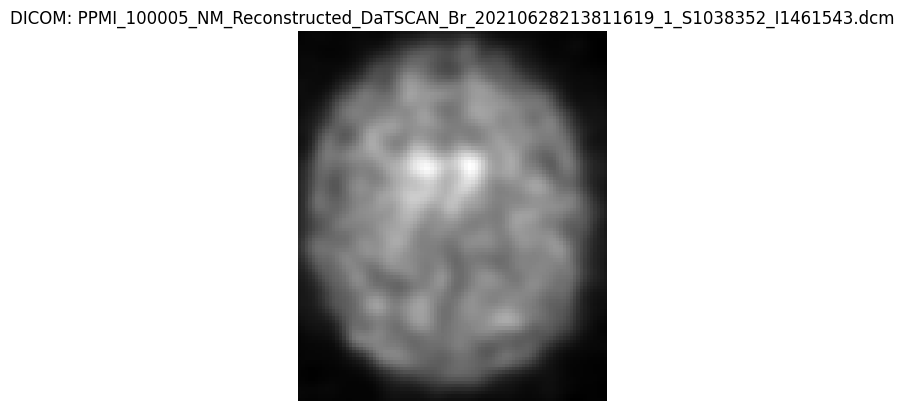

In [4]:
base_path = "Dataset/datscan_images/PPMI"

displayed_count = 0
MAX_DISPLAYED = 10

for patient_id in os.listdir(base_path):
    patient_path = os.path.join(base_path, patient_id)
    if not os.path.isdir(patient_path):
        continue

    for scan_type in os.listdir(patient_path):
        scan_type_path = os.path.join(patient_path, scan_type)
        if not os.path.isdir(scan_type_path):
            continue

        for scan_date in os.listdir(scan_type_path):
            scan_date_path = os.path.join(scan_type_path, scan_date)
            if not os.path.isdir(scan_date_path):
                continue

            for image_id in os.listdir(scan_date_path):
                image_folder_path = os.path.join(scan_date_path, image_id)
                if not os.path.isdir(image_folder_path):
                    continue

                for file in os.listdir(image_folder_path):
                    if file.lower().endswith(".dcm"):
                        dicom_file = os.path.join(image_folder_path, file)
                        display_dicom_image(dicom_file)
                        displayed_count += 1
                        break

                if displayed_count >= MAX_DISPLAYED:
                    break
            if displayed_count >= MAX_DISPLAYED:
                break
        if displayed_count >= MAX_DISPLAYED:
            break
    if displayed_count >= MAX_DISPLAYED:
        break

### 1. Conversion from DICOM to NIfTI

In [5]:
def display_nifti_img(data, ax=None, title="", axis="z"):
    # Take middle slice in x-axis
    if axis == "x":
        x_middle = data.shape[0] // 2
        slice_img = data[x_middle, :, :]

    # Take middle slice in y-axis
    elif axis == "y":
        y_middle = data.shape[1] // 2
        slice_img = data[:, y_middle, :]

    # Take middle slice in z-axis
    else:
        z_middle = data.shape[2] // 2
        slice_img = data[:, :, z_middle]

    if ax is None:
        # Display standalone
        plt.imshow(np.rot90(slice_img), cmap='gray')
        plt.title(title)
        plt.axis('off')
        plt.show()
    else:
        # Display in provided axis
        ax.imshow(np.rot90(slice_img), cmap='gray')
        ax.set_title(title)
        ax.axis('off')


[1/3836] Converting: patient 100001 - image I1452480....


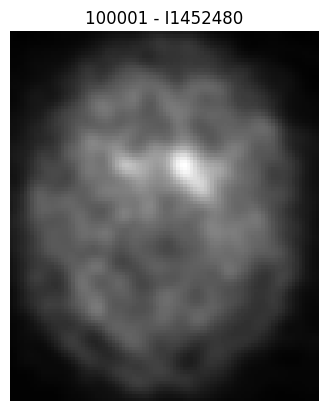


[2/3836] Converting: patient 100001 - image I1518598....


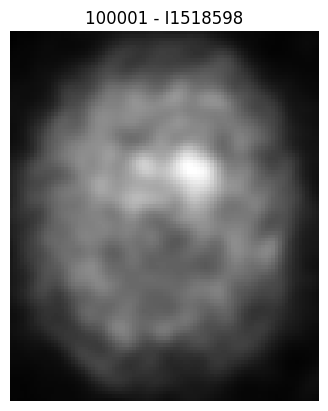


[3/3836] Converting: patient 100001 - image I1530341....


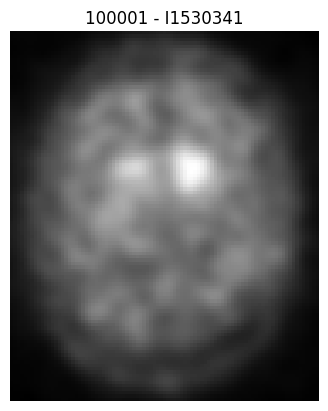


[4/3836] Converting: patient 100001 - image I1582833....


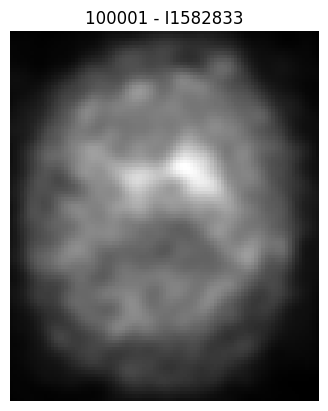


[5/3836] Converting: patient 100001 - image I1660691....


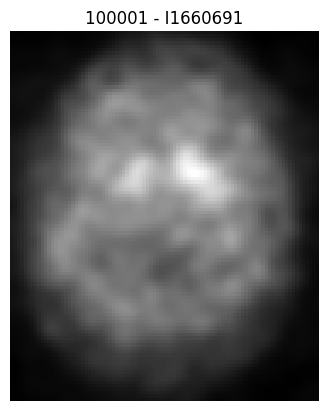


[6/3836] Converting: patient 100001 - image I10960001....


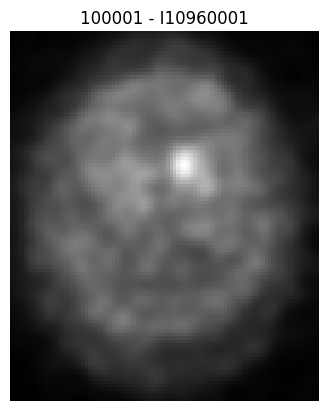


[7/3836] Converting: patient 100002 - image I1474774....


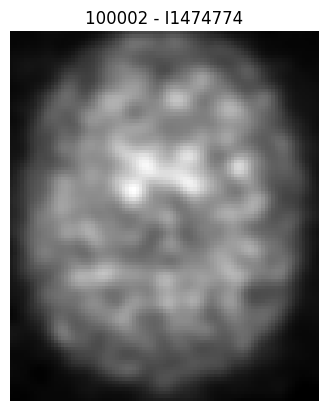


[8/3836] Converting: patient 100002 - image I1537899....


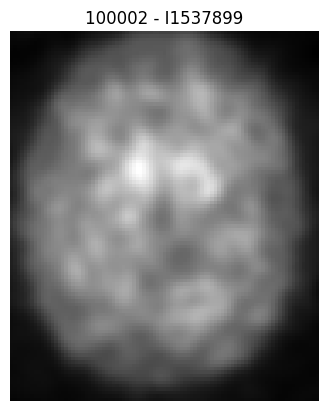


[9/3836] Converting: patient 100004 - image I1461542....


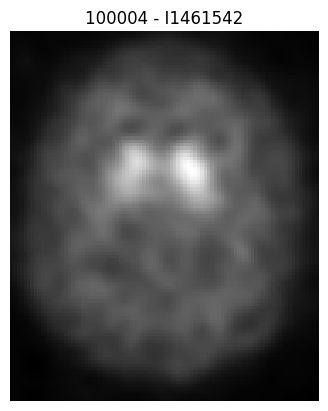


[10/3836] Converting: patient 100005 - image I1461543....


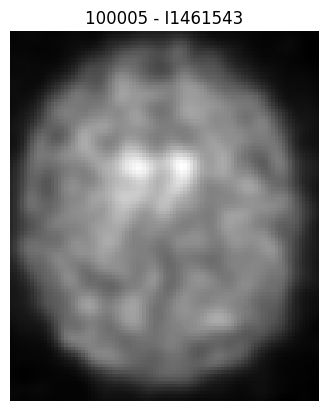


[11/3836] Converting: patient 100005 - image I1548448....

[12/3836] Converting: patient 100006 - image I1461544....

[13/3836] Converting: patient 100006 - image I1537900....

[14/3836] Converting: patient 100006 - image I10380466....

[15/3836] Converting: patient 100007 - image I1461545....

[16/3836] Converting: patient 100007 - image I1548449....

[17/3836] Converting: patient 100007 - image I10380467....

[18/3836] Converting: patient 100012 - image I1461546....

[19/3836] Converting: patient 100012 - image I1573146....

[20/3836] Converting: patient 100012 - image I1671552....

[21/3836] Converting: patient 100017 - image I1474775....

[22/3836] Converting: patient 100017 - image I1619847....

[23/3836] Converting: patient 100017 - image I1671556....

[24/3836] Converting: patient 100018 - image I1461547....

[25/3836] Converting: patient 100018 - image I1603132....

[26/3836] Converting: patient 100018 - image I10380468....

[27/3836] Converting: patient 100267 - image I146154

KeyboardInterrupt: 

In [ ]:
total_images = 3839 - 3 # images that failed to denoise
processed_count = 0
displayed_count = 0
failed_images = []

nifti_path = "Dataset/datscan_images/Converted_NIfTI"
os.makedirs(nifti_path, exist_ok=True)

def convert_with_dcm2niix(dicom_folder, output_file):
    try:
        output_dir = os.path.dirname(output_file)
        os.makedirs(output_dir, exist_ok=True)

        subprocess.run([
            "NeuroImaging_Tools/dcm2niix/dcm2niix.exe",
            "-z", "y",                # gzip compress
            "-f", "temp_convert",     # temporary filename
            "-o", output_dir,         # output directory
            dicom_folder
        ], check=True)

        # rename files by image id
        nii_file = None
        json_file = None

        for f in os.listdir(output_dir):
            if f.startswith("temp_convert") and f.endswith(".nii.gz"):
                nii_file = f
            elif f.startswith("temp_convert") and f.endswith(".json"):
                json_file = f

        if nii_file:
            os.rename(os.path.join(output_dir, nii_file), output_file)

            if json_file:
                json_output = os.path.splitext(os.path.splitext(output_file)[0])[0] + ".json"
                os.rename(
                    os.path.join(output_dir, json_file),
                    json_output
                )
            return True

        print(f" No NIfTI file generated for {dicom_folder}")
        return False


    except subprocess.CalledProcessError as e:
        print(f" dcm2niix failed for {dicom_folder}: {e}")
        return False


for patient_id in os.listdir(base_path):
    patient_path = os.path.join(base_path, patient_id)
    if not os.path.isdir(patient_path):
        continue

    for scan_type in os.listdir(patient_path):
        scan_type_path = os.path.join(patient_path, scan_type)
        if not os.path.isdir(scan_type_path):
            continue

        for scan_date in os.listdir(scan_type_path):
            date_path = os.path.join(scan_type_path, scan_date)
            if not os.path.isdir(date_path):
                continue

            for image_id in os.listdir(date_path):
                image_folder = os.path.join(date_path, image_id)
                if not os.path.isdir(image_folder):
                    continue

                processed_count += 1
                print(f"\n[{processed_count}/{total_images}] Converting: patient {patient_id} - image {image_id}....")

                patient_output_dir = os.path.join(nifti_path, patient_id)
                os.makedirs(patient_output_dir, exist_ok=True)
                output_file = os.path.join(patient_output_dir, f"{image_id}.nii.gz")

                try:
                    if not convert_with_dcm2niix(image_folder, output_file):
                        failed_images.append(f"{patient_id}/{image_id}")
                        continue

                    # Display NIfTI images
                    if displayed_count < MAX_DISPLAYED and os.path.exists(output_file):
                        try:
                            img = nib.load(output_file)
                            data = img.get_fdata()
                            display_nifti_img(data, title=f"{patient_id} - {image_id}")
                            displayed_count += 1
                        except Exception as e:
                            print(f" Failed to display {output_file}: {e}")
                            failed_images.append(f"{patient_id}/{image_id}")

                except Exception as e:
                    print(f" Unexpected error processing {patient_id}/{image_id}: {e}")
                    failed_images.append(f"{patient_id}/{image_id}")


# ==== FINAL SUMMARY ====
print("\n" + "="*50)
if not failed_images:
    print(" All images converted successfully")
else:
    print(f" {len(failed_images)} images failed to convert:")
    for img in failed_images:
        print(f" - {img}")

### 2 Denoising using BM3D (Block-matching and 3D filtering )

⚠ 3 images failed to denoise (paired):
 - patient 3372 - image I1317554 
 - patient 4092 - image I449046
 - patient 50028 - image I1273880

also (unpaired):
- patient 242895 - image I10381824
- patient 3378 - image I1317557

 Skipping (already processed): 100001 - I10960001
 Skipping (already processed): 100001 - I1452480
 Skipping (already processed): 100001 - I1518598
 Skipping (already processed): 100001 - I1530341
 Skipping (already processed): 100001 - I1582833
 Skipping (already processed): 100001 - I1660691
 Skipping (already processed): 100002 - I1474774
 Skipping (already processed): 100002 - I1537899
 Skipping (already processed): 100004 - I1461542
 Skipping (already processed): 100005 - I1461543
 Skipping (already processed): 100006 - I1461544
 Skipping (already processed): 100007 - I1461545
 Skipping (already processed): 100012 - I1461546
 Skipping (already processed): 100017 - I1474775
 Skipping (already processed): 100017 - I1619847
 Skipping (already processed): 100018 - I1461547
 Skipping (already processed): 100267 - I10380475
 Skipping (already processed): 100267 - I1461548
 Skipping (already processed): 100268 - I1461549
 Skipping (already processed): 100268 - I1616053
 Skipping (already

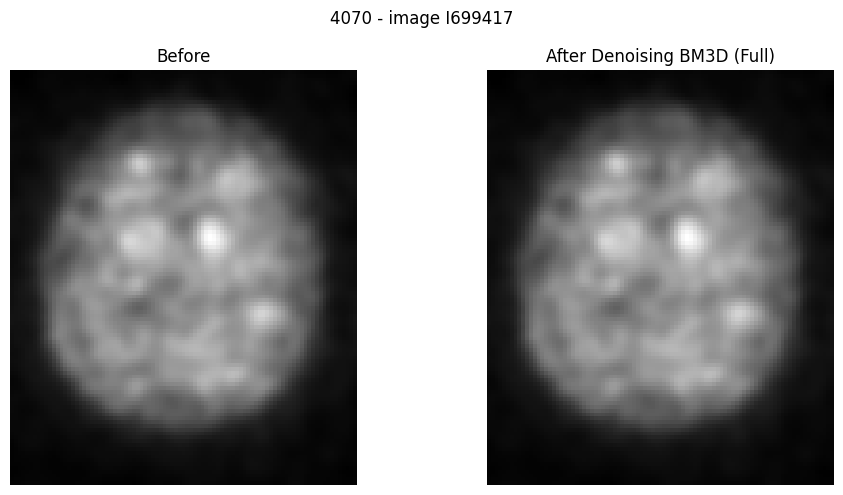


[2556/2846] BM3D Denoising: patient 40702 - image I453720....
--> Estimated sigma: 0.5426


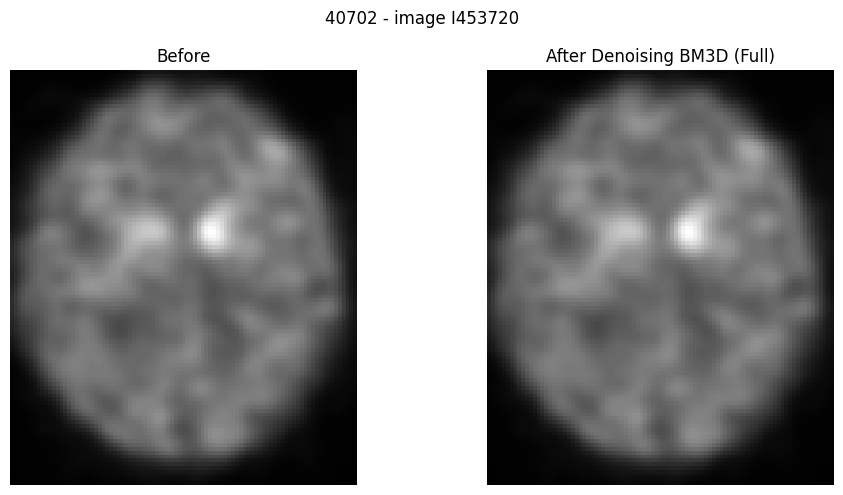


[2557/2846] BM3D Denoising: patient 40703 - image I453721....
--> Estimated sigma: 0.8008


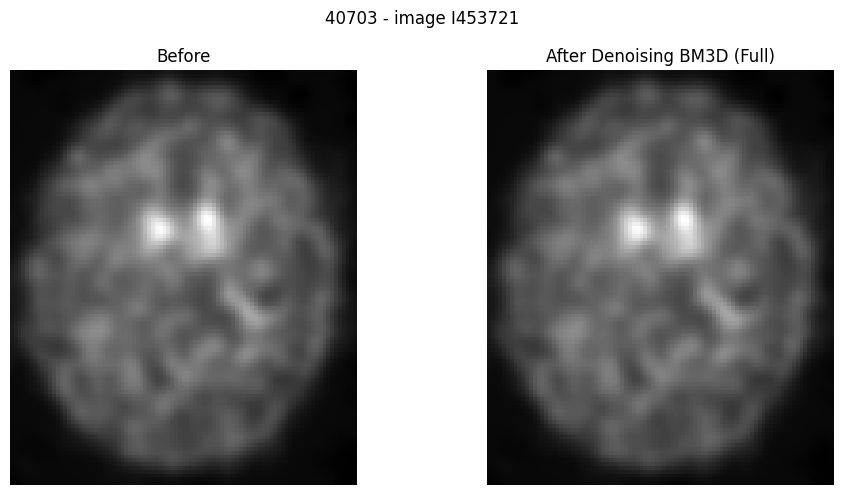


[2558/2846] BM3D Denoising: patient 40704 - image I453722....
--> Estimated sigma: 0.5043


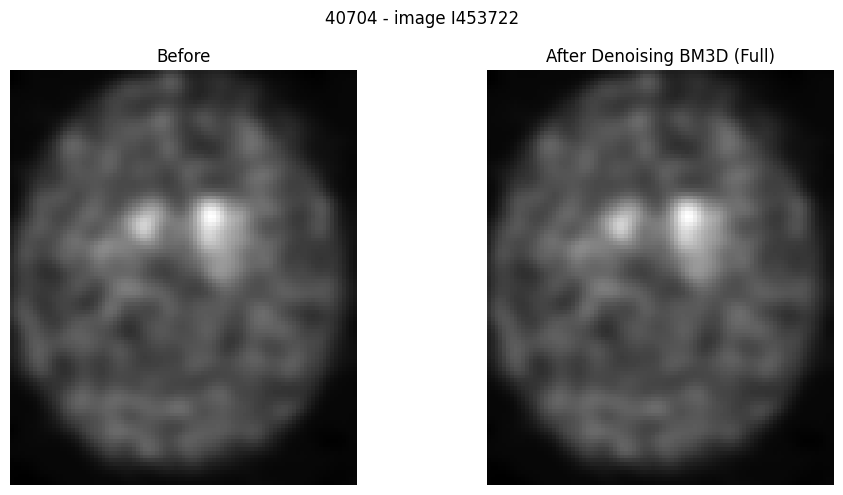


[2559/2846] BM3D Denoising: patient 40707 - image I453723....
--> Estimated sigma: 0.6514


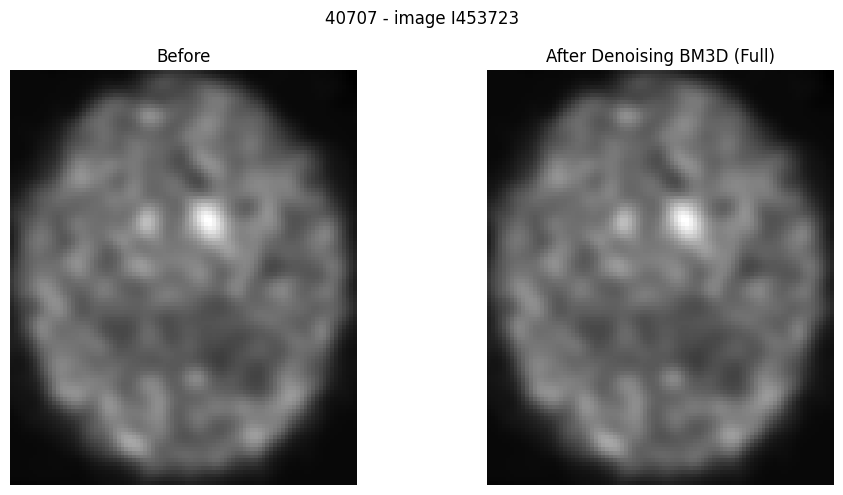


[2560/2846] BM3D Denoising: patient 40709 - image I1275278....
--> Estimated sigma: 0.6081


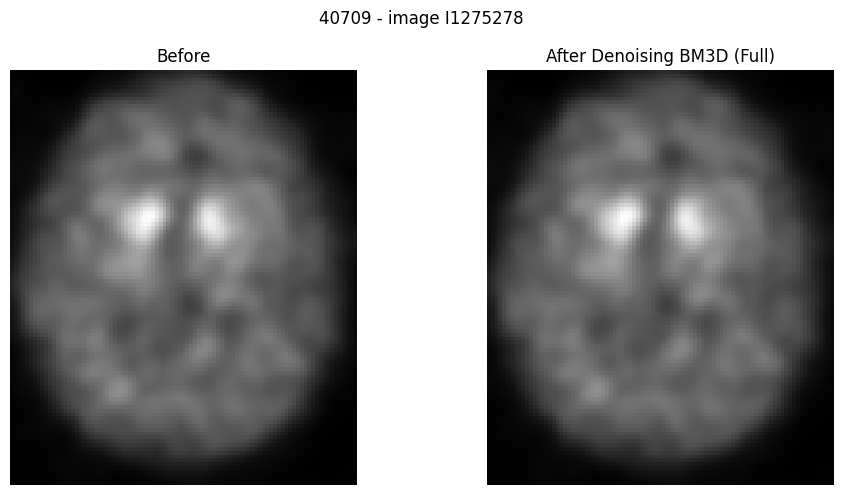


[2561/2846] BM3D Denoising: patient 40709 - image I453724....
--> Estimated sigma: 0.8430


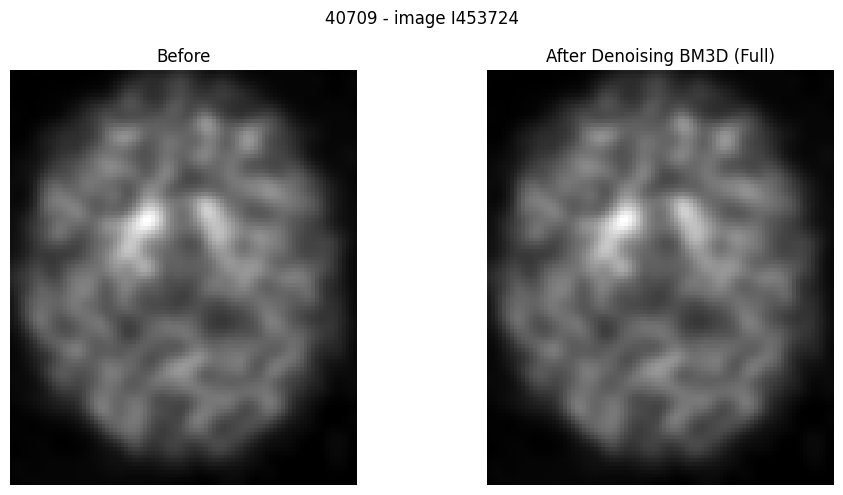


[2562/2846] BM3D Denoising: patient 4071 - image I355249....
--> Estimated sigma: 1.5327


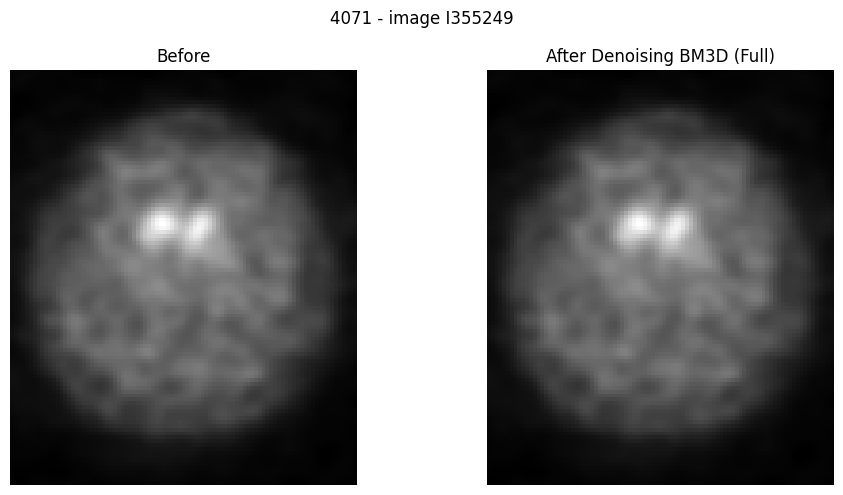


[2563/2846] BM3D Denoising: patient 4071 - image I418716....
--> Estimated sigma: 1.1633


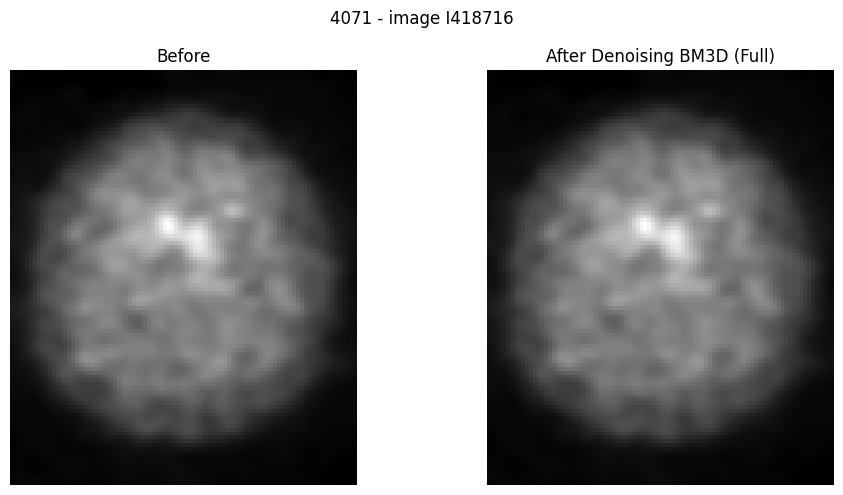


[2564/2846] BM3D Denoising: patient 40713 - image I1298254....
--> Estimated sigma: 0.5426


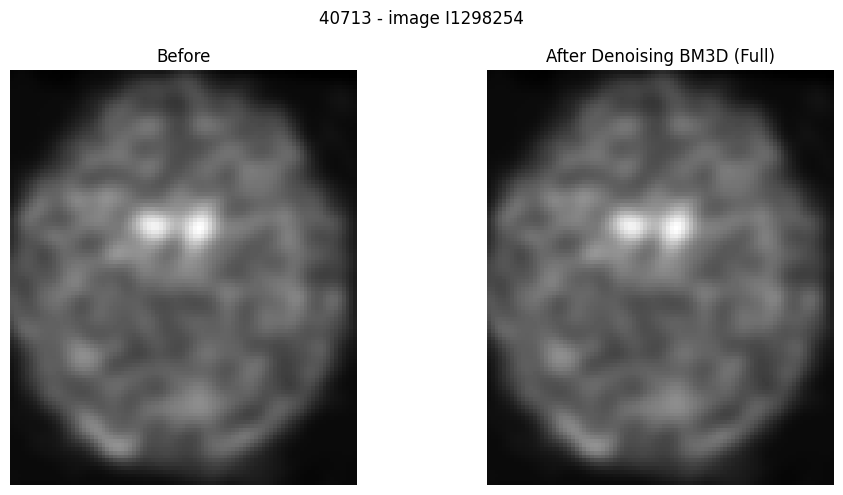


[2565/2846] BM3D Denoising: patient 40713 - image I453725....
--> Estimated sigma: 0.5394

[2566/2846] BM3D Denoising: patient 40714 - image I1275279....
--> Estimated sigma: 0.4739

[2567/2846] BM3D Denoising: patient 40714 - image I453726....
--> Estimated sigma: 0.5130

[2568/2846] BM3D Denoising: patient 4072 - image I355250....
--> Estimated sigma: 0.7377

[2569/2846] BM3D Denoising: patient 4072 - image I418717....
--> Estimated sigma: 0.5043

[2570/2846] BM3D Denoising: patient 407230 - image I11083702....
--> Estimated sigma: 0.0023

[2571/2846] BM3D Denoising: patient 4073 - image I1129415....
--> Estimated sigma: 0.7041

[2572/2846] BM3D Denoising: patient 4073 - image I354350....
--> Estimated sigma: 0.6848

[2573/2846] BM3D Denoising: patient 40730 - image I505039....
--> Estimated sigma: 1.9942

[2574/2846] BM3D Denoising: patient 40730 - image I912227....
--> Estimated sigma: 2.9753

[2575/2846] BM3D Denoising: patient 40731 - image I505040....
--> Estimated sigma: 1.452

In [ ]:
total_images = sum(
    1 for root, dirs, files in os.walk(nifti_path)
    for file in files if file.endswith(".nii") or file.endswith(".nii.gz")
)
processed_count = 0
displayed_count = 0
failed_denoising = []


denoised_path = "Dataset/datscan_images/bm3d_full/paired/Denoised_NIfTI"
os.makedirs(denoised_path, exist_ok=True)

for root, dirs, files in os.walk(nifti_path):
    for file in files:
        if not (file.endswith(".nii") or file.endswith(".nii.gz")):
            continue

        processed_count += 1

        patient_id = os.path.basename(root)
        img_id = os.path.splitext(os.path.splitext(file)[0])[0]

        input_path = os.path.join(root, file)

        patient_output_dir = os.path.join(denoised_path, patient_id)
        os.makedirs(patient_output_dir, exist_ok=True)
        output_file = os.path.join(patient_output_dir, f"{img_id}.nii.gz")

        # skip if already done
        if os.path.exists(output_file):
            print(f" Skipping (already processed): {patient_id} - {img_id}")
            continue

        print(f"\n[{processed_count}/{total_images}] BM3D Denoising: patient {patient_id} - image {img_id}....")

        try:
            # Load image
            img = nib.load(input_path)
            data = img.get_fdata()

            # Estimate noise sigma
            sigma_est = np.mean(estimate_sigma(data, channel_axis=None))
            print(f"--> Estimated sigma: {sigma_est:.4f}")

            # BM3D works slice by slice (2D)
            denoised_data = np.zeros_like(data)

            for z in range(data.shape[2]):
                slice_img = data[:, :, z]

                denoised_slice = bm3d(
                    slice_img,
                    sigma_psd=sigma_est,
                    profile=BM3DProfile(),  # default profile
                )
                denoised_data[:, :, z] = denoised_slice

            # display BEFORE/AFTER
            if displayed_count < MAX_DISPLAYED:
                fig, axes = plt.subplots(1, 2, figsize=(10, 5))
                plt.suptitle(f"{patient_id} - image {img_id}")

                display_nifti_img(data, ax=axes[0], title="Before")
                display_nifti_img(denoised_data, ax=axes[1], title="After Denoising BM3D (Full)")

                plt.tight_layout()
                plt.show()

                displayed_count += 1

            # save denoised image
            nib.save(
                nib.Nifti1Image(denoised_data, affine=img.affine, header=img.header),
                output_file
            )

        except Exception as e:
            print(f" Failed denoising {patient_id}/{img_id}: {e}")
            failed_denoising.append(f"{patient_id}/{img_id}")


# ==== FINAL SUMMARY ====
print("\n" + "=" * 50)
if not failed_denoising:
    print(" All images denoised successfully")
else:
    print(f" {len(failed_denoising)} images failed to denoise:")
    for img_name in failed_denoising:
        print(f" - {img_name}")

### 3. Normalization (Z-score)

[✔] Skipping (already processed): 100001 - I10960001
[✔] Skipping (already processed): 100001 - I1452480
[✔] Skipping (already processed): 100001 - I1518598
[✔] Skipping (already processed): 100001 - I1530341
[✔] Skipping (already processed): 100001 - I1582833
[✔] Skipping (already processed): 100001 - I1660691
[✔] Skipping (already processed): 100002 - I1474774
[✔] Skipping (already processed): 100002 - I1537899
[✔] Skipping (already processed): 100004 - I1461542
[✔] Skipping (already processed): 100005 - I1461543
[✔] Skipping (already processed): 100006 - I1461544
[✔] Skipping (already processed): 100007 - I1461545
[✔] Skipping (already processed): 100012 - I1461546
[✔] Skipping (already processed): 100017 - I1474775
[✔] Skipping (already processed): 100017 - I1619847
[✔] Skipping (already processed): 100018 - I1461547
[✔] Skipping (already processed): 100267 - I10380475
[✔] Skipping (already processed): 100267 - I1461548
[✔] Skipping (already processed): 100268 - I1461549
[✔] Skippi

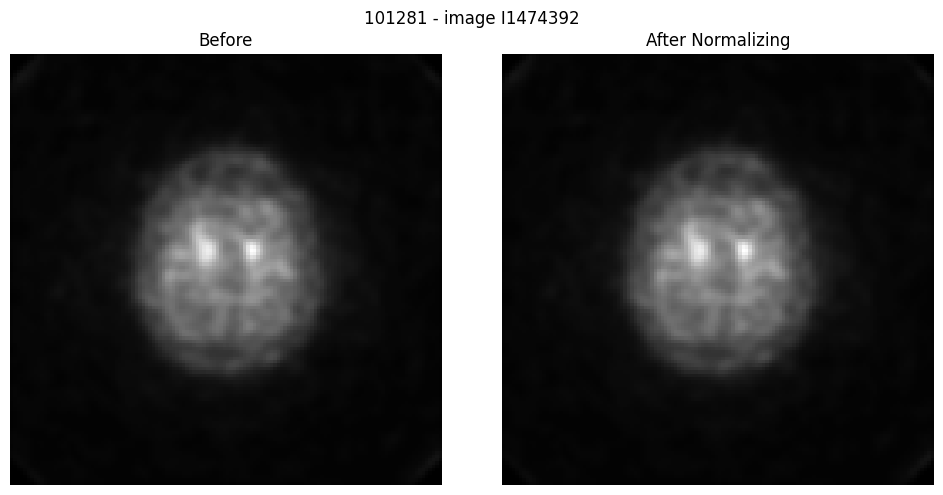

[✔] Skipping (already processed): 101291 - I1474393
[✔] Skipping (already processed): 101295 - I10395068
[✔] Skipping (already processed): 101295 - I1474394
[✔] Skipping (already processed): 101317 - I1474395
[✔] Skipping (already processed): 101329 - I1474396
[✔] Skipping (already processed): 101330 - I10380522
[✔] Skipping (already processed): 101330 - I1474397
[✔] Skipping (already processed): 101335 - I1474411
[✔] Skipping (already processed): 101344 - I10380524
[✔] Skipping (already processed): 101344 - I1474782
[✔] Skipping (already processed): 101384 - I1474398
[✔] Skipping (already processed): 101476 - I1474783
[✔] Skipping (already processed): 101476 - I1616057
[✔] Skipping (already processed): 101477 - I10380530
[✔] Skipping (already processed): 101477 - I1474399
[✔] Skipping (already processed): 101477 - I1644809
[✔] Skipping (already processed): 101479 - I1474784
[✔] Skipping (already processed): 101480 - I1486050
[✔] Skipping (already processed): 101482 - I10395069
[✔] Ski

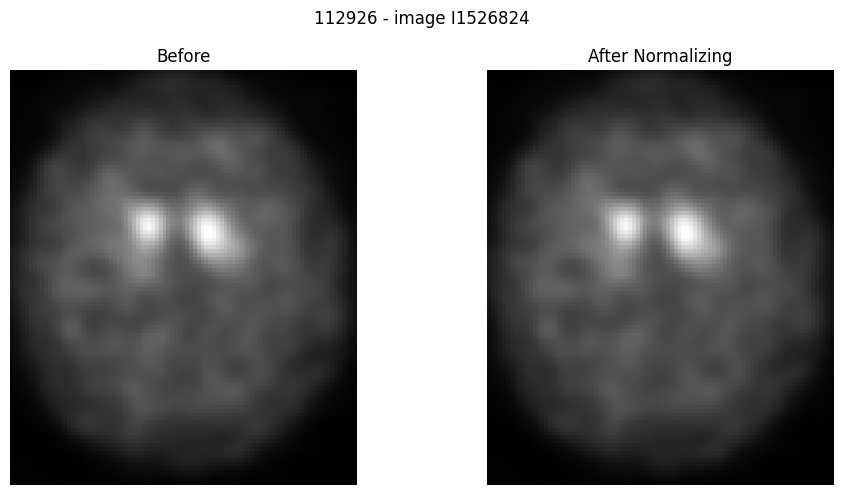


[270/788] Normalizing: patient 112926 - image I1660670....


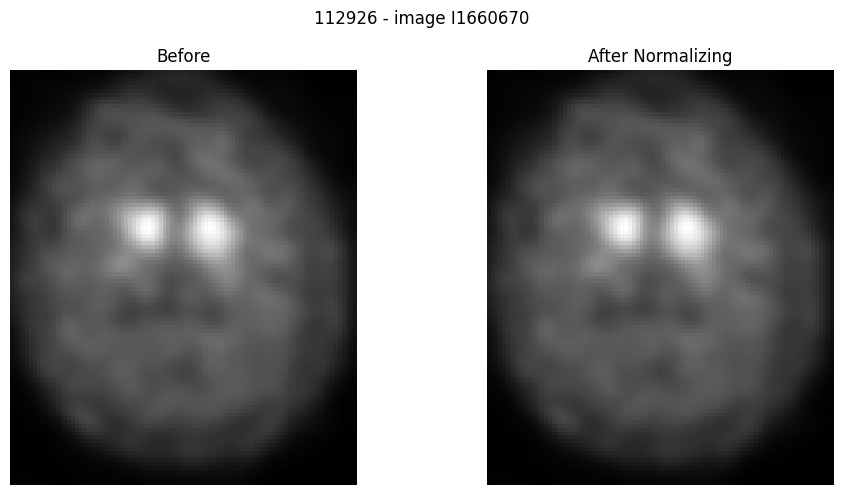


[271/788] Normalizing: patient 113043 - image I1542904....


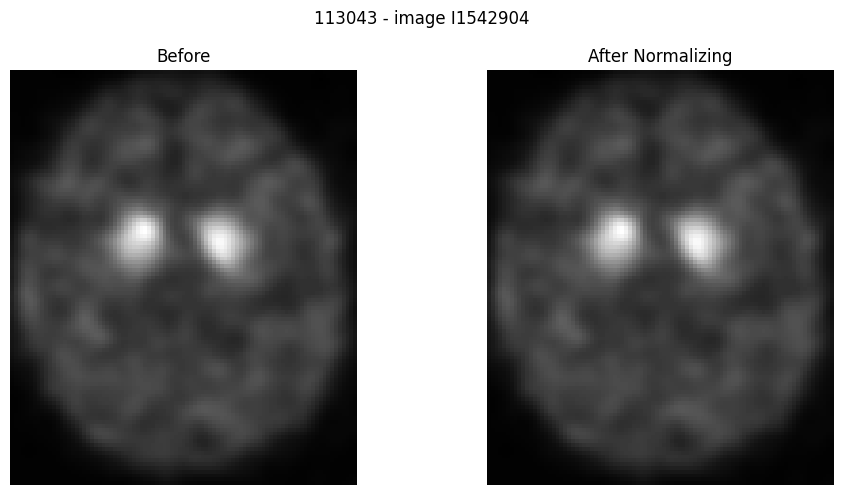


[272/788] Normalizing: patient 113050 - image I1526825....


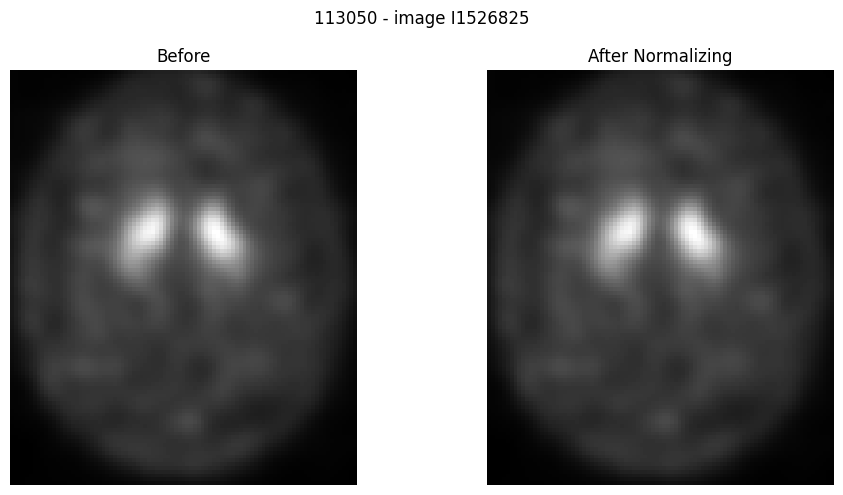


[273/788] Normalizing: patient 113355 - image I11083549....


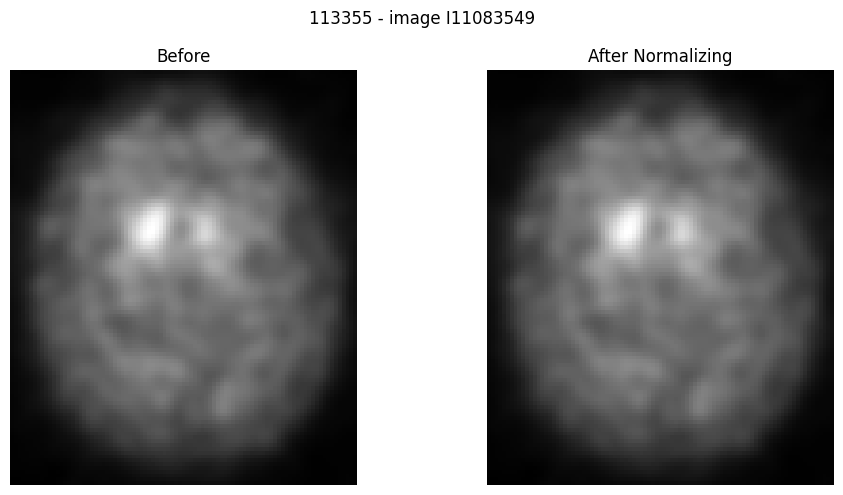


[274/788] Normalizing: patient 113355 - image I1526826....


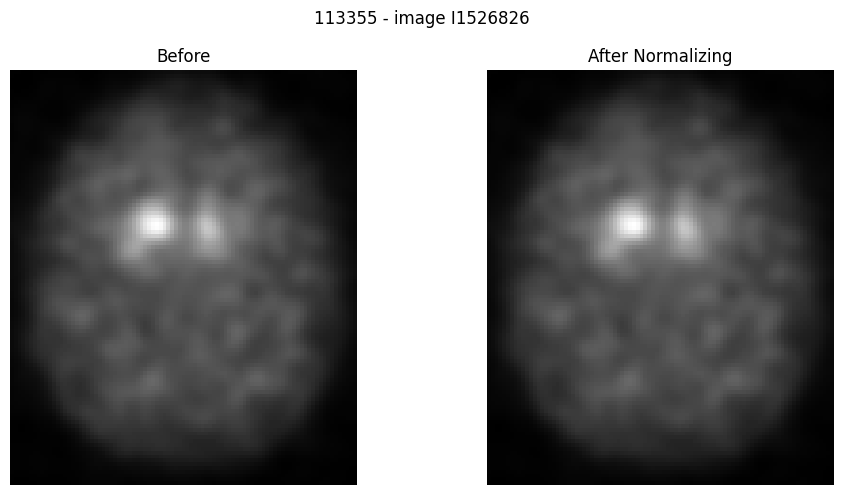


[275/788] Normalizing: patient 113355 - image I1671687....


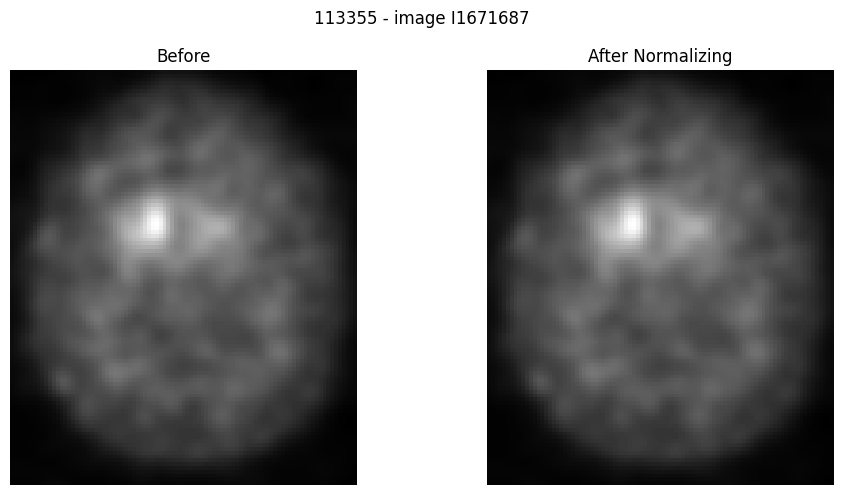


[276/788] Normalizing: patient 113366 - image I1665807....


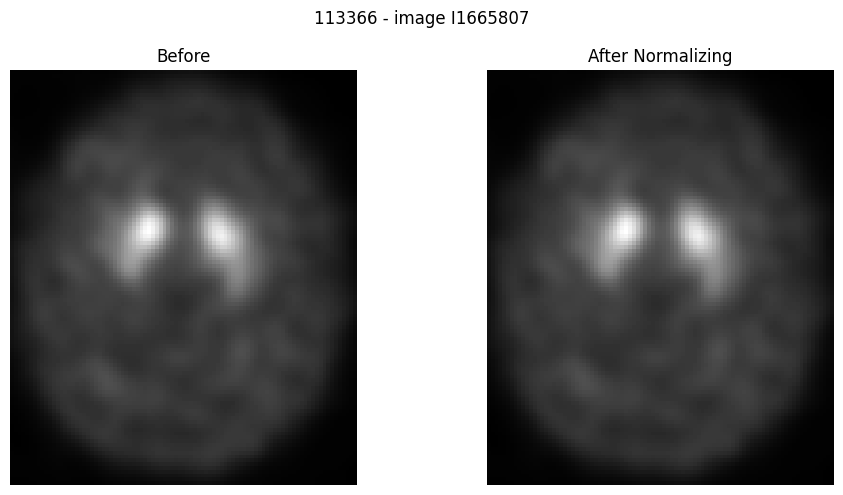


[277/788] Normalizing: patient 113369 - image I1526827....


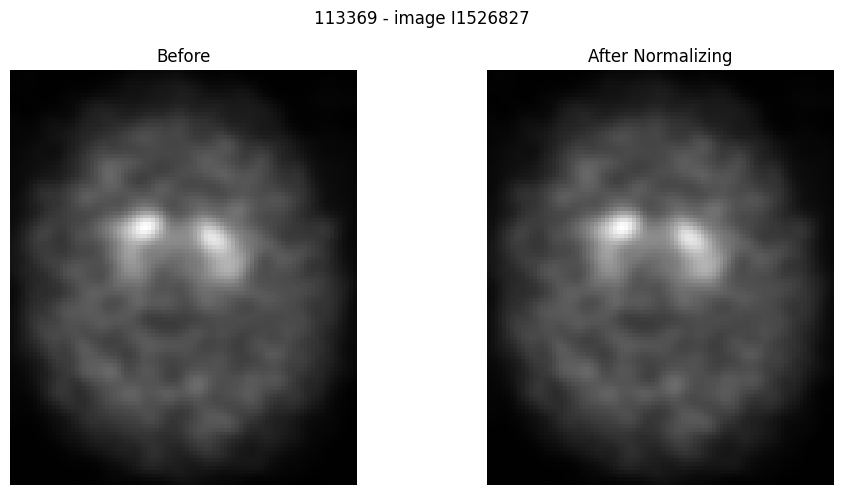


[278/788] Normalizing: patient 113446 - image I1529619....

[279/788] Normalizing: patient 113447 - image I1529620....

[280/788] Normalizing: patient 113460 - image I10380607....

[281/788] Normalizing: patient 113460 - image I10676999....

[282/788] Normalizing: patient 113460 - image I1526828....

[283/788] Normalizing: patient 113672 - image I1571461....

[284/788] Normalizing: patient 113905 - image I1529621....

[285/788] Normalizing: patient 114126 - image I1526829....

[286/788] Normalizing: patient 114137 - image I11083550....

[287/788] Normalizing: patient 114137 - image I1623685....

[288/788] Normalizing: patient 114195 - image I11083551....

[289/788] Normalizing: patient 114195 - image I1529622....

[290/788] Normalizing: patient 114195 - image I1671494....

[291/788] Normalizing: patient 114264 - image I1571462....

[292/788] Normalizing: patient 114265 - image I1542905....

[293/788] Normalizing: patient 114269 - image I1571463....

[294/788] Normalizing: patient 1142

In [ ]:
total_images = sum(
    1 for root, dirs, files in os.walk(denoised_path)
    for file in files if file.endswith(".nii") or file.endswith(".nii.gz")
)
processed_count = 0
displayed_count = 0
failed_normalization = []


normalized_path = "Dataset/datscan_images/bm3d_full/unpaired/Normalized_NIfTI"
os.makedirs(normalized_path, exist_ok=True)

for root, dirs, files in os.walk(denoised_path):
    for file in files:
        if file.endswith(".nii") or file.endswith(".nii.gz"):
            processed_count += 1

            patient_id = os.path.basename(root)
            img_id = os.path.splitext(os.path.splitext(file)[0])[0]

            input_path = os.path.join(root, file)

            patient_output_dir = os.path.join(normalized_path, patient_id)
            os.makedirs(patient_output_dir, exist_ok=True)
            output_file = os.path.join(patient_output_dir, f"{img_id}.nii.gz")

            # skip if already done
            if os.path.exists(output_file):
                print(f" Skipping (already processed): {patient_id} - {img_id}")
                continue

            print(f"\n[{processed_count}/{total_images}] Normalizing: patient {patient_id} - image {img_id}....")
            
            try:
                # Load image
                img = nib.load(input_path)
                data = img.get_fdata()

                mean = np.mean(data)
                std = np.std(data)

                # Avoid division by zero
                if std == 0:
                    print(f" Std is zero for {patient_id} image {img_id} --> skipping normalization")
                    normalized_data = data - mean
                else:
                    normalized_data = (data - mean) / std

                # display BEFORE/AFTER
                if displayed_count < MAX_DISPLAYED:
                    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
                    plt.suptitle(f"{patient_id} - image {img_id}")

                    display_nifti_img(data, ax=axes[0], title="Before")
                    display_nifti_img(normalized_data, ax=axes[1], title="After Normalizing")

                    plt.tight_layout()
                    plt.show()

                    displayed_count += 1

                # save normalized file
                nib.save(
                    nib.Nifti1Image(normalized_data, affine=img.affine, header=img.header),
                    output_file
                )

            except Exception as e:
                print(f"[✘] Failed to normalize {patient_id}/{img_id}: {e}")
                failed_normalization.append(f"{patient_id}/{img_id}")


# ==== FINAL SUMMARY ====
print("\n" + "="*50)
if not failed_normalization:
    print(" All images normalized successfully")
else:
    print(f" {len(failed_normalization)} images failed to normalize:")
    for img_name in failed_normalization:
        print(f" - {img_name}")

### 4. Striatum-centered Cropping

In [ ]:
wrong_shape_files = []

expected_shape = (91, 109, 91)

for root, _, files in os.walk(normalized_path):
    for file in files:
        if file.endswith(('.nii', '.nii.gz')):
            path = os.path.join(root, file)
            try:
                img = nib.load(path)
                actual_shape = img.shape
                if actual_shape != expected_shape:
                    wrong_shape_files.append((path, actual_shape))
            except Exception as e:
                print(f" Could not read {file}: {e}")

print(f"\n Found {len(wrong_shape_files)} images with wrong shape (not {expected_shape})")


for p, shape in wrong_shape_files:
    print(f"{p} --> shape: {shape}")


✅ Found 0 images with wrong shape (not (91, 109, 91))


In [ ]:
#  delete wrong-shape images 
for path, shape in wrong_shape_files:
    try:
        if os.path.exists(path):
            os.remove(path)
            print(f"Deleted: {path} (shape={shape})")
    except Exception as e:
        print(f" Failed to delete {path}: {e}")


# remove empty patient folders
for patient_id in os.listdir(normalized_path):
    patient_path = os.path.join(normalized_path, patient_id)

    # skip anything that is not a directory
    if not os.path.isdir(patient_path):
        continue

    # check if patient still has any NIfTI files
    has_nifti = False
    for root, _, files in os.walk(patient_path):
        for f in files:
            if f.endswith(".nii") or f.endswith(".nii.gz"):
                has_nifti = True
                break
        if has_nifti:
            break

    # remove patient folder if no NIfTI files
    if not has_nifti:
        try:
            shutil.rmtree(patient_path)
            print(f"Removed empty patient folder: {patient_path}")
        except Exception as e:
            print(f" Failed to remove {patient_path}: {e}")

Standard processed DaTSCAN volumes are typically:
- x = 91 voxels (left–right)
- y = 109 voxels (posterior–anterior)
- z = 91 voxels (inferior–superior)
- Voxel size = 2 × 2 × 2 mm³
- The data is already spatially normalized to MNI space, so the anatomical position of the striatum is consistent across subjects.


[1/986] Cropping: patient 100005 - image I1548448....


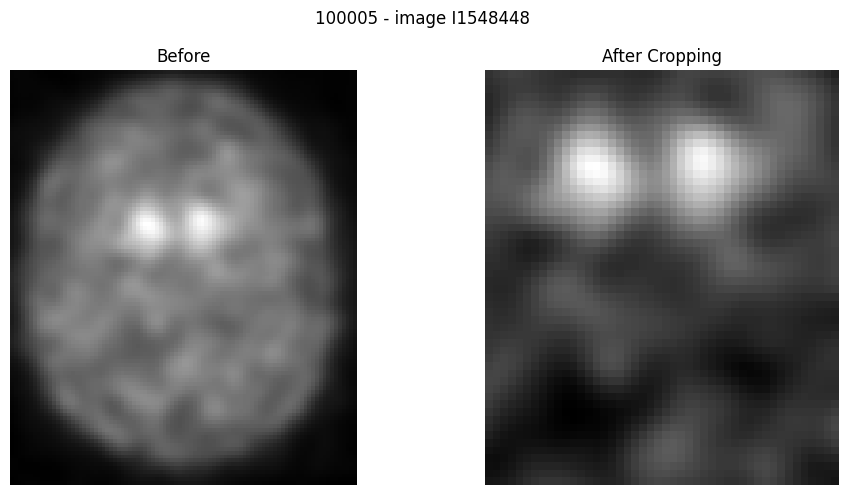


[2/986] Cropping: patient 100006 - image I10380466....


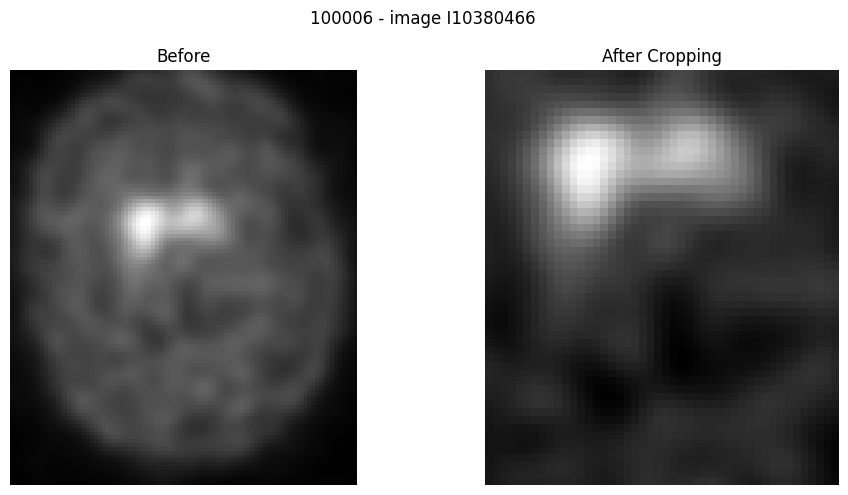


[3/986] Cropping: patient 100006 - image I1537900....


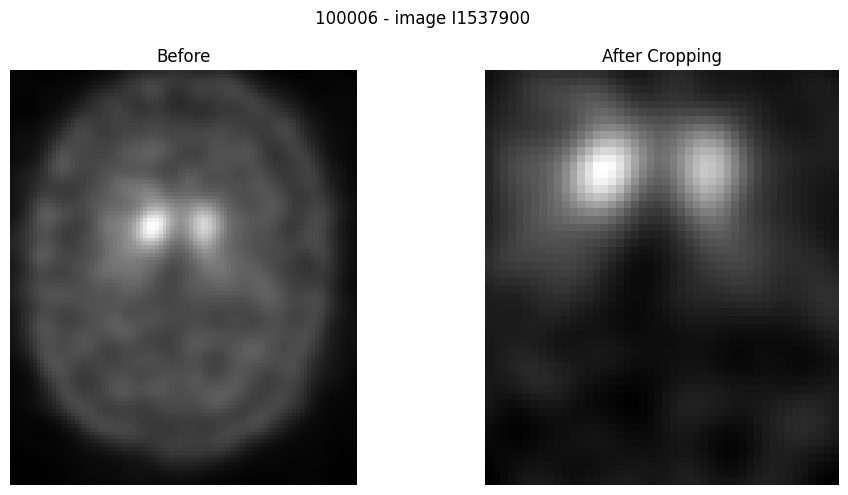


[4/986] Cropping: patient 100007 - image I10380467....


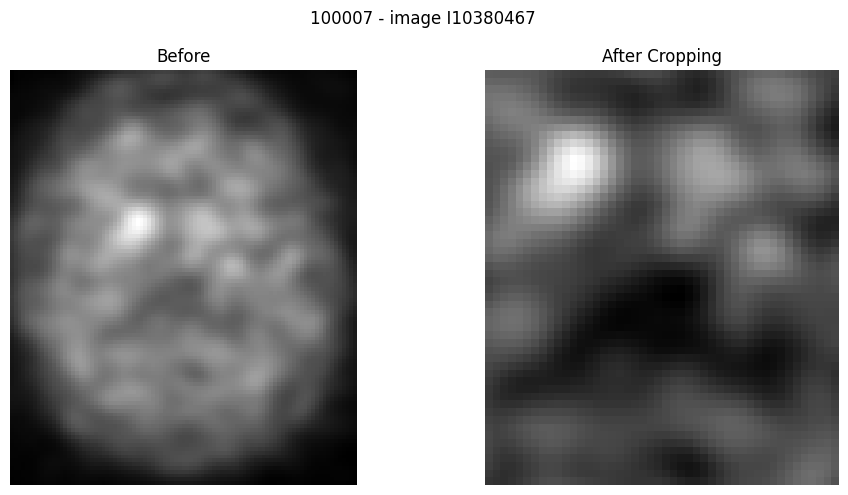


[5/986] Cropping: patient 100007 - image I1548449....


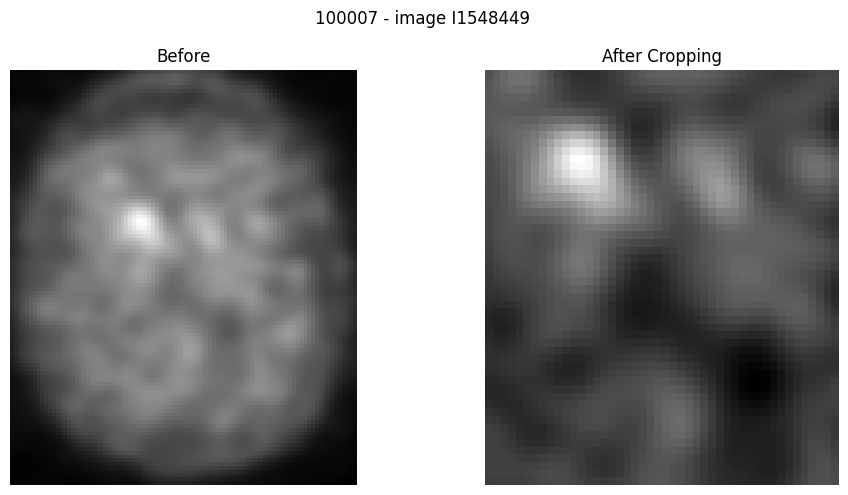


[6/986] Cropping: patient 100012 - image I1573146....


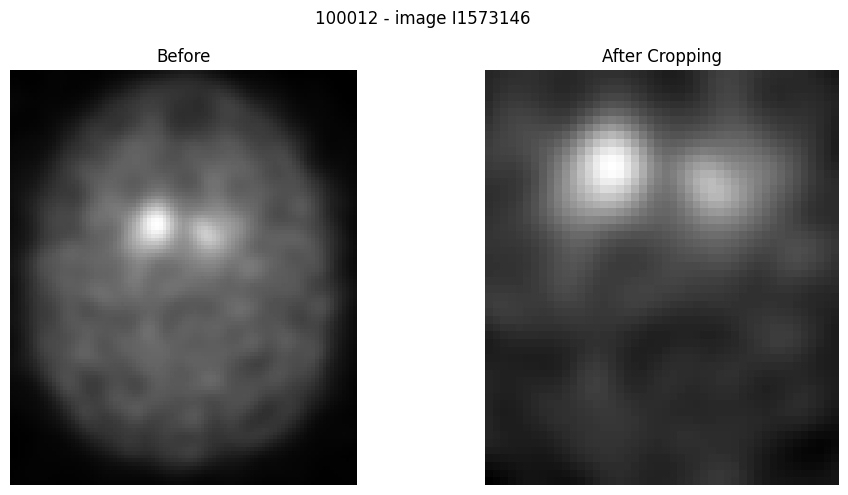


[7/986] Cropping: patient 100012 - image I1671552....


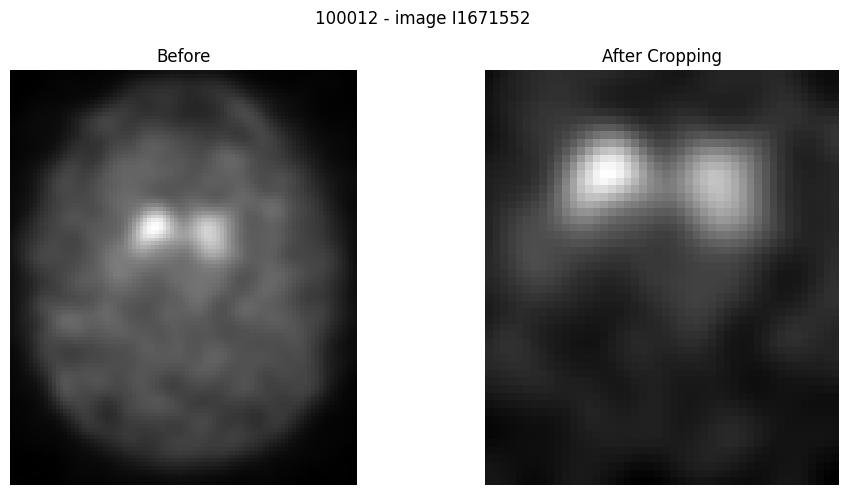


[8/986] Cropping: patient 100017 - image I1671556....


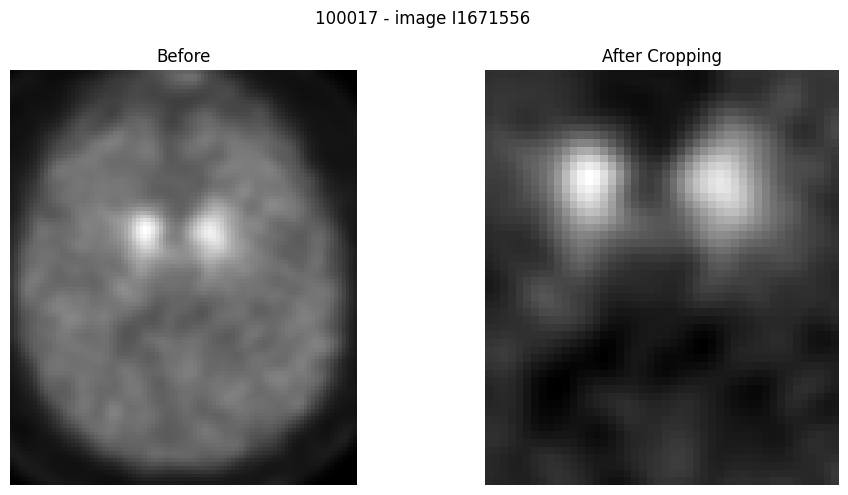


[9/986] Cropping: patient 100018 - image I10380468....


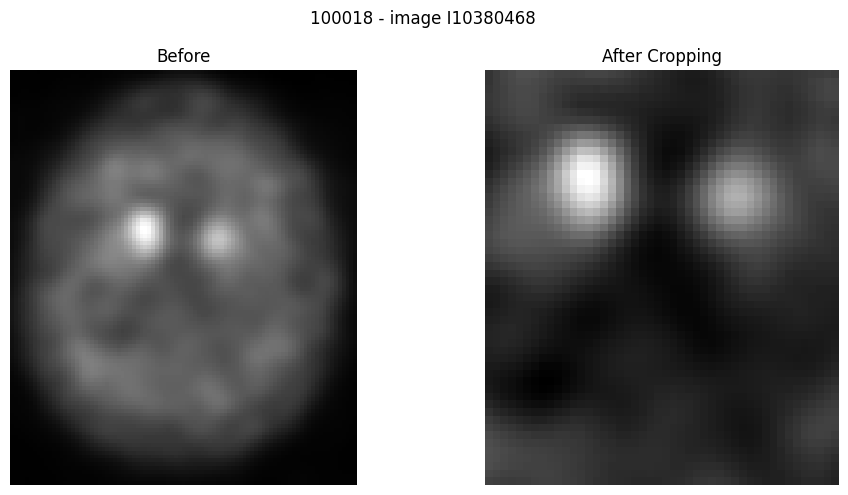


[10/986] Cropping: patient 100018 - image I1603132....


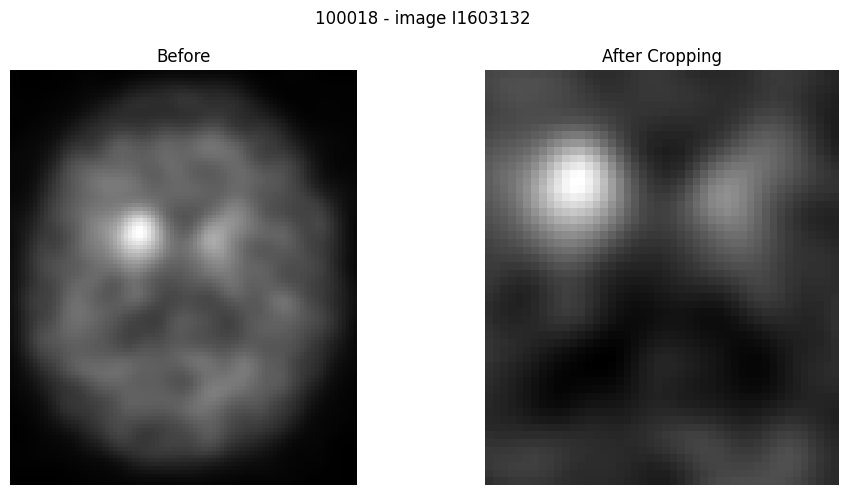


[11/986] Cropping: patient 100267 - image I1603133....

[12/986] Cropping: patient 100268 - image I10380476....

[13/986] Cropping: patient 100842 - image I10380486....

[14/986] Cropping: patient 100878 - image I1573148....

[15/986] Cropping: patient 100889 - image I10380490....

[16/986] Cropping: patient 100891 - image I1548450....

[17/986] Cropping: patient 100891 - image I1719494....

[18/986] Cropping: patient 100898 - image I1573149....

[19/986] Cropping: patient 100898 - image I1707528....

[20/986] Cropping: patient 100911 - image I10380492....

[21/986] Cropping: patient 100952 - image I10380494....

[22/986] Cropping: patient 100952 - image I1582689....

[23/986] Cropping: patient 100972 - image I1584066....

[24/986] Cropping: patient 101018 - image I10380499....

[25/986] Cropping: patient 101018 - image I1573151....

[26/986] Cropping: patient 101026 - image I1644807....

[27/986] Cropping: patient 101038 - image I10445474....

[28/986] Cropping: patient 101038 - imag

In [ ]:
total_images = sum(
    1 for root, dirs, files in os.walk(normalized_path)
    for file in files if file.endswith(".nii") or file.endswith(".nii.gz")
)
processed_count = 0
displayed_count = 0
failed_cropping = []

# ORIGINAL_SHAPE = (91, 109, 91)
CROP_SHAPE = (46, 54, 14)  # (x, y, z)

cropped_path = "Dataset/datscan_images/bm3d_full/unpaired/Cropped_NIfTI"
os.makedirs(cropped_path, exist_ok=True)

for root, dirs, files in os.walk(normalized_path):
    for file in files:
        if file.endswith(".nii") or file.endswith(".nii.gz"):
            processed_count += 1

            patient_id = os.path.basename(root)
            img_id = os.path.splitext(os.path.splitext(file)[0])[0]

            input_path = os.path.join(root, file)

            patient_output_dir = os.path.join(cropped_path, patient_id)
            os.makedirs(patient_output_dir, exist_ok=True)
            output_file = os.path.join(patient_output_dir, f"{img_id}.nii.gz")

            # skip if already done
            if os.path.exists(output_file):
                print(f" Skipping (already processed): {patient_id} - {img_id}")
                continue
            
            print(f"\n[{processed_count}/{total_images}] Cropping: patient {patient_id} - image {img_id}....")

            try:
                # load image
                img = nib.load(input_path)
                data = img.get_fdata()

                # compute center crop coordinates
                cx, cy, cz = np.array(data.shape) // 2
                dx, dy, dz = np.array(CROP_SHAPE) // 2

                # crop boundaries
                x_start, x_end = cx - dx, cx + dx
                y_start, y_end = cy - dy, cy + dy
                z_start, z_end = cz - dz, cz + dz

                cropped_data = data[x_start:x_end, y_start:y_end, z_start:z_end]

                # display BEFORE/AFTER
                if displayed_count < MAX_DISPLAYED:
                    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
                    plt.suptitle(f"{patient_id} - image {img_id}")

                    display_nifti_img(data, ax=axes[0], title="Before")
                    display_nifti_img(cropped_data, ax=axes[1], title="After Cropping")

                    plt.tight_layout()
                    plt.show()

                    displayed_count += 1

                # save cropped image
                nib.save(
                    nib.Nifti1Image(cropped_data, affine=img.affine, header=img.header),
                    output_file
                )

            except Exception as e:
                print(f" Failed to crop {patient_id}/{img_id}: {e}")
                failed_cropping.append(f"{patient_id}/{img_id}")


# ==== FINAL SUMMARY ====
print("\n" + "="*50)
if not failed_cropping:
    print(" All images cropped successfully")
else:
    print(f" {len(failed_cropping)} images failed to crop:")
    for img_name in failed_cropping:
        print(f" - {img_name}")

## Merge all PPMI_ (DaTscan) folders

### check for duplicates patients

In [ ]:
from collections import defaultdict

# Path where PPMI_1 to PPMI_5 folders live
base_path = "Dataset/datscan_images"

# Store patients by which PPMI folder they appear in
patient_folders = defaultdict(list)

# Loop over each PPMI folder
for folder_name in sorted(os.listdir(base_path)):
    folder_path = os.path.join(base_path, folder_name)

    if os.path.isdir(folder_path) and folder_name.startswith("PPMI_"):
        # Each patient is usually a subfolder (adjust if stored differently)
        for patient_id in os.listdir(folder_path):
            patient_folders[patient_id].append(folder_name)

# Find duplicates
duplicates = {pid: locations for pid, locations in patient_folders.items() if len(locations) > 1}

# Report results
if duplicates:
    print("⚠ Found patients in multiple PPMI folders:")
    for pid, locations in duplicates.items():
        print(f" - Patient {pid} found in: {', '.join(locations)}")
else:
    print("✅ No duplicate patients found across PPMI_1 to PPMI_5")


⚠ Found patients in multiple PPMI folders:
 - Patient 100001 found in: PPMI_1, PPMI_2, PPMI_3, PPMI_5
 - Patient 100005 found in: PPMI_1, PPMI_3
 - Patient 100006 found in: PPMI_1, PPMI_2, PPMI_5
 - Patient 100012 found in: PPMI_1, PPMI_3
 - Patient 100017 found in: PPMI_1, PPMI_3
 - Patient 100018 found in: PPMI_1, PPMI_4
 - Patient 100268 found in: PPMI_1, PPMI_3, PPMI_4
 - Patient 100889 found in: PPMI_1, PPMI_3, PPMI_4
 - Patient 100891 found in: PPMI_1, PPMI_2
 - Patient 100898 found in: PPMI_1, PPMI_2, PPMI_3
 - Patient 100911 found in: PPMI_1, PPMI_3, PPMI_4
 - Patient 100952 found in: PPMI_1, PPMI_2, PPMI_5
 - Patient 101018 found in: PPMI_1, PPMI_5
 - Patient 101026 found in: PPMI_1, PPMI_3, PPMI_4
 - Patient 101038 found in: PPMI_1, PPMI_2, PPMI_5
 - Patient 101047 found in: PPMI_1, PPMI_2, PPMI_3, PPMI_4
 - Patient 101070 found in: PPMI_1, PPMI_5
 - Patient 101174 found in: PPMI_1, PPMI_3, PPMI_5
 - Patient 101179 found in: PPMI_1, PPMI_3, PPMI_5
 - Patient 101186 found in: 

### check for duplicates images per patient

In [18]:
# Step 1: Map patients to which PPMI folders they appear in
patient_folders = defaultdict(list)

for folder_name in sorted(os.listdir(base_path)):
    folder_path = os.path.join(base_path, folder_name)

    if os.path.isdir(folder_path) and folder_name.startswith("PPMI_"):
        for patient_id in os.listdir(folder_path):
            patient_path = os.path.join(folder_path, patient_id)
            if os.path.isdir(patient_path):
                patient_folders[patient_id].append(patient_path)

# Step 2: Check duplicates by image_id (last folder name)
duplicates = {pid: paths for pid, paths in patient_folders.items() if len(paths) > 1}

if not duplicates:
    print("✅ No duplicate patients found.")
else:
    print(f"⚠ Found {len(duplicates)} duplicate patients.\n")

    for patient_id, paths in duplicates.items():
        image_id_sets = []

        for path in paths:
            image_ids = set()
            for root, dirs, files in os.walk(path):
                # If this folder has no subfolders and contains files, it's an image_id folder
                if files and not dirs:
                    image_id = os.path.basename(root)
                    image_ids.add(image_id)
            image_id_sets.append(image_ids)

        # Compare all sets of image_ids
        identical = all(image_id_sets[0] == ids for ids in image_id_sets[1:])

        print(f"Patient {patient_id}: {'YES - identical image IDs' if identical else 'NO - different image IDs'}")


⚠ Found 857 duplicate patients.

Patient 100001: NO - different image IDs
Patient 100005: NO - different image IDs
Patient 100006: NO - different image IDs
Patient 100012: NO - different image IDs
Patient 100017: NO - different image IDs
Patient 100018: NO - different image IDs
Patient 100268: NO - different image IDs
Patient 100889: NO - different image IDs
Patient 100891: NO - different image IDs
Patient 100898: NO - different image IDs
Patient 100911: NO - different image IDs
Patient 100952: NO - different image IDs
Patient 101018: NO - different image IDs
Patient 101026: NO - different image IDs
Patient 101038: NO - different image IDs
Patient 101047: NO - different image IDs
Patient 101070: NO - different image IDs
Patient 101174: NO - different image IDs
Patient 101179: NO - different image IDs
Patient 101186: NO - different image IDs
Patient 101221: NO - different image IDs
Patient 101279: NO - different image IDs
Patient 101295: NO - different image IDs
Patient 101330: NO - dif

### merge all 5 folders

In [ ]:
import shutil


# Destination: merged single PPMI folder
output_dir = os.path.join(base_path, "PPMI")
os.makedirs(output_dir, exist_ok=True)

# Map: patient_id -> set of image_ids (to avoid duplicates)
patient_image_ids = defaultdict(set)

# Walk through all PPMI folders
for folder_name in sorted(os.listdir(base_path)):
    folder_path = os.path.join(base_path, folder_name)

    if os.path.isdir(folder_path) and folder_name.startswith("PPMI_"):
        for patient_id in os.listdir(folder_path):
            patient_path = os.path.join(folder_path, patient_id)
            if not os.path.isdir(patient_path):
                continue

            # Destination patient folder
            merged_patient_path = os.path.join(output_dir, patient_id)
            os.makedirs(merged_patient_path, exist_ok=True)

            # Walk through the substructure of each patient
            for scan_type in os.listdir(patient_path):
                scan_type_path = os.path.join(patient_path, scan_type)
                if not os.path.isdir(scan_type_path):
                    continue

                for date_folder in os.listdir(scan_type_path):
                    date_path = os.path.join(scan_type_path, date_folder)
                    if not os.path.isdir(date_path):
                        continue

                    for image_id in os.listdir(date_path):
                        image_id_path = os.path.join(date_path, image_id)
                        if not os.path.isdir(image_id_path):
                            continue

                        # Skip duplicate image_ids for the same patient
                        if image_id in patient_image_ids[patient_id]:
                            continue

                        # Mark image_id as seen
                        patient_image_ids[patient_id].add(image_id)

                        # Destination path preserving structure
                        merged_image_path = os.path.join(
                            merged_patient_path, scan_type, date_folder, image_id
                        )
                        os.makedirs(os.path.dirname(merged_image_path), exist_ok=True)

                        # Copy the entire image_id folder
                        shutil.copytree(image_id_path, merged_image_path)

print("✅ Merge complete! Output stored in:", output_dir)

✅ Merge complete! Output stored in: Dataset\PPMI_MERGED


### verify total number of patients and images

#### in the 5 folders

In [ ]:
ppmi_folders = [
    "Dataset/datscan_images/PPMI_1",
    "Dataset/datscan_images/PPMI_2",
    "Dataset/datscan_images/PPMI_3",
    "Dataset/datscan_images/PPMI_4",
    "Dataset/datscan_images/PPMI_5"
]

all_patients = set()
total_unique_images = 0

for folder in ppmi_folders:
    for patient_id in os.listdir(folder):
        patient_path = os.path.join(folder, patient_id)
        if not os.path.isdir(patient_path):
            continue

        all_patients.add(patient_id)

        # Track unique image IDs for this patient inside this folder
        patient_image_ids = set()

        for scan_type in os.listdir(patient_path):
            scan_type_path = os.path.join(patient_path, scan_type)
            if not os.path.isdir(scan_type_path):
                continue

            for date_folder in os.listdir(scan_type_path):
                date_path = os.path.join(scan_type_path, date_folder)
                if not os.path.isdir(date_path):
                    continue

                for image_id in os.listdir(date_path):
                    if os.path.isdir(os.path.join(date_path, image_id)):
                        patient_image_ids.add(image_id)

        total_unique_images += len(patient_image_ids)

print(f"📌 Total unique patients: {len(all_patients)}")
print(f"📌 Total unique image IDs: {total_unique_images}")

📌 Total unique patients: 2033
📌 Total unique image IDs: 3839


#### in the merged folder

In [ ]:
merged_path = "Dataset/datscan_images/PPMI"

all_patients = set()
total_unique_images = 0

for patient_id in os.listdir(merged_path):
    patient_path = os.path.join(merged_path, patient_id)
    if not os.path.isdir(patient_path):
        continue

    all_patients.add(patient_id)

    # Track unique image IDs for this patient
    patient_image_ids = set()

    for scan_type in os.listdir(patient_path):
        scan_type_path = os.path.join(patient_path, scan_type)
        if not os.path.isdir(scan_type_path):
            continue

        for date_folder in os.listdir(scan_type_path):
            date_path = os.path.join(scan_type_path, date_folder)
            if not os.path.isdir(date_path):
                continue

            for image_id in os.listdir(date_path):
                if os.path.isdir(os.path.join(date_path, image_id)):
                    patient_image_ids.add(image_id)

    # Add this patient's unique image count to the total
    total_unique_images += len(patient_image_ids)

print(f"📌 Total unique patients: {len(all_patients)}")
print(f"📌 Total unique image IDs: {total_unique_images}")

📌 Total unique patients: 2033
📌 Total unique image IDs: 3836
